In [235]:
using BSON: @load
using CSV
using Dates
using DriftDiffusionModels
using HiddenMarkovModels
using MultivariateStats
using LinearAlgebra
using Clustering
using DataFrames
using HypothesisTests
using Distances
using StatsBase
using StatsPlots
using Plots
using Turing
using MCMCChains
using CategoricalArrays
using Base.Threads: @threads

## Preprocessing

In [2]:
# set data dirtectory
data_dir = joinpath(@__DIR__, "..", "data")

# read out all BSOn files that have a 4 in them (K=4)
bson_files = filter(f -> occursin("K4", f), readdir(data_dir; join=true))

# read all data into a bson file. We need to define the following struct for it to work right.
struct DDMHMMFit
    hmm::PriorHMM
    logL::Float64
    logL_evolution::Vector{Float64}
end

ddmhmm_fits = DDMHMMFit[]  

for bson_file in bson_files
    @load bson_file fit   # defines `fit` in this scope
    push!(ddmhmm_fits, fit)
end

In [3]:
ddm_params = Matrix{Float64}(undef, 4, 18 * 4) # 4 parameters per DDM, (18 subjects x 4 states)

for (i, fit) in enumerate(ddmhmm_fits)
    for k in 1:4
        ddm = fit.hmm.dists[k]
        ddm_params[:, (i - 1) * 4 + k] = [ddm.v, ddm.B, ddm.a₀, ddm.τ]
    end
end

ddm_params_df = DataFrame(ddm_params', [:v, :B, :a0, :tau])
animal_files = [split(fname, "\\")[end] for fname in bson_files]
animal_name  = [split(file, "_")[1] for file in animal_files]

ddm_params_df.rat = repeat(animal_name, inner=4);

ddm_params_clean = Matrix(select(ddm_params_df, Not(:rat))) # for numerical analyses

# standardize first if need later
zscore(x; dims) = (x .- mean(x; dims=dims)) ./ std(x; dims=dims)
ddm_params_z = zscore(ddm_params_clean'; dims=2)

4×72 Matrix{Float64}:
  0.0884106   0.0123428  -0.159011  …  -0.623018    -0.135475   -0.299235
 -0.329032   -0.153295   -0.494668      0.00684298  -0.333599   -0.473151
 -1.05581    -0.630828   -0.70414      -0.186832    -0.236163    0.290069
  0.833301    1.09977     0.424557     -2.15416     -0.0134415  -0.466619

## Compare Parameters between models

In [4]:
accs = Vector{Float64}(undef, size(ddm_params_df, 1))
mean_rt = Vector{Float64}(undef, size(ddm_params_df, 1))
for (idx, i) in enumerate(eachrow(ddm_params_df))
    ddm = DriftDiffusionModels.DriftDiffusionModel(v=i.v, B=i.B, a₀=i.a0, τ=i.tau)
    data = simulateDDM(ddm, 10000)
    is_correct = [d.s == d.choice for d in data]
    rts = [d.rt for d in data]
    accs[idx] = mean(is_correct)
    mean_rt[idx] = mean(rts)
end
ddm_params_df.acc = accs;
ddm_params_df.mean_rt = mean_rt;

In [67]:
ddm_params_df

Row,v,B,a0,tau,rat,acc,mean_rt
,Float64,Float64,Float64,Float64,SubStrin…,Float64,Float64
1,0.800873,1.47002,0.292321,0.754848,1029,0.712,1.16292
2,0.725818,1.8118,0.358132,0.822089,1029,0.7675,1.50098
3,0.556746,1.14789,0.346779,0.651706,1029,0.6464,0.942347
4,0.612275,1.69357,0.302977,0.518806,1029,0.6962,1.0948
5,0.727369,1.52206,0.519774,0.44123,1052,0.7543,0.970899
6,0.845505,1.81247,0.379647,0.682955,1052,0.8059,1.34491
7,0.661512,2.44532,0.792997,0.698185,1052,0.7292,1.55883
8,0.891777,1.46226,0.536375,0.573163,1052,0.7891,1.04142
9,0.221718,1.8506,0.167597,0.0790191,1054,0.5603,0.550473


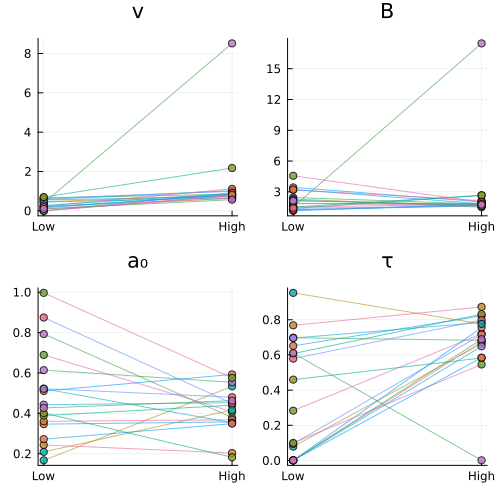

In [25]:

function high_low_by_rat(df::DataFrame; acc::Symbol=:acc)
    g = groupby(df, :rat)

    high = combine(g) do sdf
        sdf[argmax(sdf[!, acc]), :]
    end

    low = combine(g) do sdf
        sdf[argmin(sdf[!, acc]), :]
    end

    rename!(high, Symbol.(names(high)) .=> Symbol.(string.(names(high)) .* "_high"))
    rename!(low,  Symbol.(names(low))  .=> Symbol.(string.(names(low))  .* "_low"))

    return innerjoin(high, low, on = :rat_high => :rat_low)
end

hl = high_low_by_rat(ddm_params_df)

hl.Δv   = hl.v_high   .- hl.v_low
hl.ΔB   = hl.B_high   .- hl.B_low
hl.Δa0  = hl.a0_high  .- hl.a0_low
hl.Δτ   = hl.tau_high .- hl.tau_low

function paired_spaghetti(hl::DataFrame, low::Symbol, high::Symbol; title="")
    lo = hl[!, low]
    hi = hl[!, high]
    n = length(lo)

    p = plot(size =(500,500), xticks=([1,2], ["Low", "High"]), title=title, legend=false)
    for i in 1:n
        plot!(p, [1,2], [lo[i], hi[i]], lw=1, alpha=0.6)
        scatter!(p, [1,2], [lo[i], hi[i]], alpha=0.8, ms=4)
    end

    return p
end

delta_tau = paired_spaghetti(hl, :tau_low, :tau_high; title="τ")
delta_a0  = paired_spaghetti(hl, :a0_low,  :a0_high;  title="a₀")
delta_B   = paired_spaghetti(hl, :B_low,   :B_high;   title="B")
delta_v   = paired_spaghetti(hl, :v_low,   :v_high;   title="v")

param_diff_plot = plot(delta_v, delta_B, delta_a0, delta_tau; layout=(2,2))
# savefig(param_diff_plot, "../results/param_diff_plot_population.svg")

In [28]:
function paired_tests(hl::DataFrame, Δ::Symbol)
    x = skipmissing(hl[!, Δ]) |> collect

    t  = OneSampleTTest(x)      # mean(Δ) = 0
    w  = SignedRankTest(x)      # median(Δ) = 0 (robust default)

    return (
        n = length(x),
        mean = mean(x),
        median = median(x),
        t_p = pvalue(t),
        w_p = pvalue(w),
    )
end

paired_tests(hl, :Δv)

(n = 18, mean = 1.0024526641262332, median = 0.5843623953178843, t_p = 0.030705299135637458, w_p = 7.62939453125e-6)

In [ ]:
hl.bias_best = hl.a0_high .- 0.5
hl.bias_2worst  = hl.a0_low  .- 0.5
SignedRankTest(hl.bias_best) |> pvalue
SignedRankTest(hl.bias_2worst)  |> pvalue

18-element Vector{Float64}:
 -0.15322086769446558
  0.29299697149744786
 -0.3324027874175953
 -0.13940793631910076
 -0.1107893613782045
 -0.05705763348679038
  0.022469553452539537
  0.18946905820707804
  0.011012010065420408
  0.11405332943944624
 -0.2906713774418699
 -0.25623240148043425
 -0.09850905841603469
  0.021746474185370235
  0.3744889347762992
  0.4965852565987061
 -0.22759144691796962
 -0.07311295451841626

## Within-Animal SAT

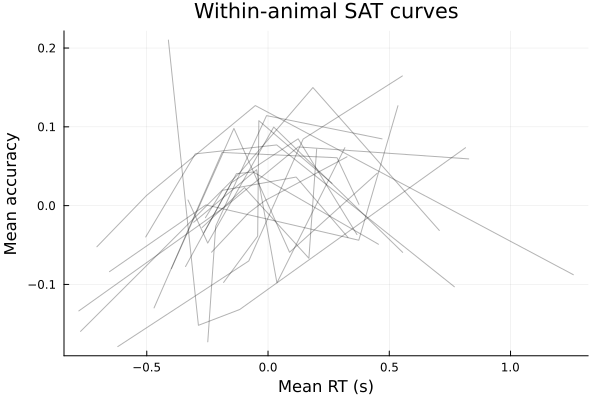

In [34]:
# SAT curvs
function center_within_animal(df::DataFrame;
    rat::Symbol=:rat, rt::Symbol=:mean_rt, acc::Symbol=:mean_acc)

    g = groupby(df, rat)

    return DataFrames.transform(g,
        rt  => (x -> x .- mean(x))  => :rt_c,
        acc => (x -> x .- mean(x))  => :acc_c,
    )
end

dfc = center_within_animal(ddm_params_df; rat=:rat, rt=:mean_rt, acc=:acc)

function plot_sat_spaghetti(df::DataFrame;
    rt::Symbol=:mean_rt,
    acc::Symbol=:acc,
    rat::Symbol=:rat,
    title::String="Within-animal SAT curves")

    p = plot(title=title, xlabel="Mean RT (s)", ylabel="Mean accuracy",
             legend=false)

    for sdf in groupby(df, rat)
        # sort points within animal by RT so the line doesn't jump around
        ord = sortperm(sdf[!, rt])
        x = sdf[ord, rt]
        y = sdf[ord, acc]

        plot!(p, x, y, lw=1, color=:black, alpha=0.3)

    end

    return p
end

p = plot_sat_spaghetti(dfc; rt=:rt_c, acc=:acc_c, rat=:rat)

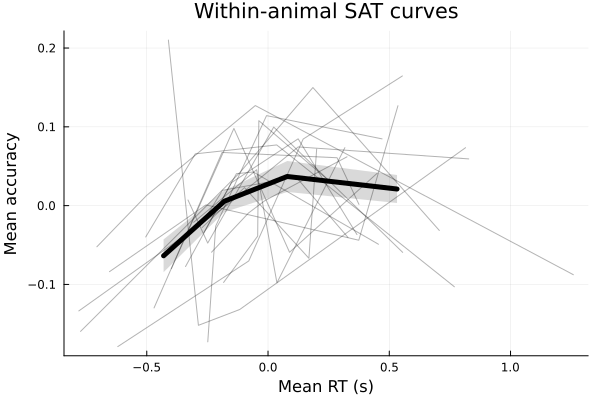

In [35]:
# 1) add within-rat RT order (1..K)
function add_rt_order(df::DataFrame; rat::Symbol=:rat, rt::Symbol=:rt_c)
    g = groupby(df, rat)
    return DataFrames.transform(g, rt => (x -> invperm(sortperm(x))) => :rt_order)
end

# 2) overlay mean SAT curve (+/- SEM ribbon) onto an existing plot
function overlay_mean_sat!(p, df::DataFrame;
    rt::Symbol=:rt_c, acc::Symbol=:acc_c, order::Symbol=:rt_order)

    summ = combine(groupby(df, order),
        rt  => mean => :rt_mean,
        acc => mean => :acc_mean,
        acc => (x -> std(x)/sqrt(length(x))) => :acc_sem
    )
    sort!(summ, order)

    plot!(p, summ.rt_mean, summ.acc_mean, lw=5, alpha=1.0, color=:black)
    plot!(p, summ.rt_mean, summ.acc_mean, ribbon=summ.acc_sem, fillalpha=0.15, color=:black,lw=0)
    return p
end

dfc2 = add_rt_order(dfc; rat=:rat, rt=:rt_c)

overlay_mean_sat!(p, dfc2; rt=:rt_c, acc=:acc_c, order=:rt_order)

p

# savefig(p, "../results/population_mean_sat.svg")

## Calculate Regression between model parameters and accuracy

In [140]:
@model function parameter_regression(ddm_params)
    N, P = size(ddm_params)

    β ~ MvNormal(zeros(P), I)
    ϕ ~ Exponential(1.0)

    η = ddm_params * β
    p = logistic.(η)       # mean in (0,1)

    ϵ = 1e-6
    p = clamp.(p, ϵ, 1 - ϵ)

    for n in 1:N
        a = p[n] * ϕ
        b = (1 - p[n]) * ϕ
        acc[n] ~ Beta(a, b)
    end
end

ddm_params_reg = select(ddm_params_df, [:v, :B, :a0, :tau]) |> Matrix
ddm_params_reg = zscore(ddm_params_reg; dims=1)
ddm_params_reg = hcat(ddm_params_reg, ones(size(ddm_params_reg, 1)))  # add intercept



acc = ddm_params_df.acc |> collect
acc = clamp.(acc, 1e-6, 1 - 1e-6)

model = parameter_regression(acc, ddm_params_reg)
chain = sample(model, NUTS(0.65), 5000; progress=true)

Sampling   0%|█                                         |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference C:\Users\senne\.julia\packages\Turing\lmRwJ\src\mcmc\hmc.jl:220
Sampling   0%|█                                         |  ETA: 0:00:03
Sampling   1%|█                                         |  ETA: 0:00:03
Sampling   2%|█                                         |  ETA: 0:00:03
Sampling   2%|█                                         |  ETA: 0:00:03
Sampling   2%|██                                        |  ETA: 0:00:03
Sampling   3%|██                                        |  ETA: 0:00:03
Sampling   4%|██                                        |  ETA: 0:00:03
Sampling   4%|██                                        |  ETA: 0:00:03
Sampling   4%|██                                        |  ETA: 0:00:03
Sampling   5%|███                                       |  ETA: 0:00:03
Sampling   6%|███                                       |  ETA: 0:00:03
Sampling   

Chains MCMC chain (5000×20×1 Array{Float64, 3}):

Iterations        = 1001:1:6000
Number of chains  = 1
Samples per chain = 5000
Wall duration     = 2.68 seconds
Compute duration  = 2.68 seconds
parameters        = β[1], β[2], β[3], β[4], β[5], ϕ
internals         = n_steps, is_accept, acceptance_rate, log_density, hamiltonian_energy, hamiltonian_energy_error, max_hamiltonian_energy_error, tree_depth, numerical_error, step_size, nom_step_size, lp, logprior, loglikelihood

Use `describe(chains)` for summary statistics and quantiles.


In [164]:
N = length(acc)
acc_miss = Vector{Union{Missing, Float64}}(missing, N)

pp_model = parameter_regression(acc_miss, ddm_params_reg)
pp = predict(pp_model, chain)

mean_acc = Vector{Float64}(undef, N)
for n in 1:N
    mean_acc[n] = mean(pp[Symbol("acc[$n]")])
end

In [ ]:
scat_plot = scatter(acc, mean_acc;
    xlabel="Observed accuracy",
    ylabel="Predicted accuracy",
    aspect_ratio = :equal, 
    xlims=(0.5, 1.0),
    ylims=(0.5, 1.0))

plot!([0.5, 1.0], [0.5, 1.0], lc=:red, ls=:dash, label="")
savefig(scat_plot, "../results/acc_pred_population.svg")

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\results\\acc_pred_population.svg"

In [ ]:
β_raw = Matrix{Float64}(undef, 5000, 5)  # 4 params + intercept
for i in 1:5
    β_raw[:, i] = chain[Symbol("β[$i]")]
end

beta_df = DataFrame(β_raw, [:v, :B, :a0, :tau, :intercept])
beta_long = stack(beta_df; variable_name=:param, value_name=:beta)

summ = combine(groupby(beta_long, :param),
    :beta => mean => :mean,
    :beta => (x -> quantile(x, 0.025)) => :lo,
    :beta => (x -> quantile(x, 0.975)) => :hi
)

summ.param = string.(summ.param)
order = ["v", "B", "a0", "tau", "intercept"]

# reorder rows according to order
summ = leftjoin(DataFrame(param=order, idx=1:length(order)), summ, on=:param)
sort!(summ, :idx)

y = 1:nrow(summ)
forest_plot = plot()
scatter!(summ.mean, y;
    xerror = (summ.mean .- summ.lo, summ.hi .- summ.mean),
    yticks = (y, summ.param),
    xlabel = "βᵢ",
    ylabel = "",
    legend = false,
    markersize = 6
)

vline!([0.0], ls=:dash, label="")

savefig(forest_plot, "../results/beta_forest_population.svg")


"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\results\\beta_forest_population.svg"

In [244]:
const _dt_formats = (
    dateformat"yyyy-mm-dd HH:MM:SS.s",
    dateformat"yyyy-mm-dd HH:MM:SS",
    dateformat"yyyy-mm-ddTHH:MM:SS.s",
    dateformat"yyyy-mm-ddTHH:MM:SS",
)

parse_dt(x) = x isa DateTime ? x :
              x isa Date     ? DateTime(x) :
              begin
                  s = String(x)
                  for df in _dt_formats
                      try
                          return DateTime(s, df)
                      catch
                      end
                  end
                  error("Couldn't parse trial_datetime string: $x. Add your format to _dt_formats.")
              end

function load_rat_data(rat::AbstractString;
    data_file = joinpath(@__DIR__, "..", "data", "processed_rat_data.csv.gz"),
)

    # Read in and structure data
    rat_df = CSV.read(data_file, DataFrame)
    rat_df = rat_df[rat_df.daily .== "24 hr", :] # only keep 24 hour data

    # preprocess the data to have numerics
    replace!(rat_df[!, :choose_right], 0 => -1)

    mapping = Dict("right" => 1, "left" => -1)
    DataFrames.transform!(rat_df,
        :correct_side => ByRow(cs -> get(mapping, cs, missing)) => :correct_side_numeric
    )

    rat_of_interest = rat_df[rat_df.name .== rat, :]

    # parse trial dates
    dts = parse_dt.(rat_of_interest.trial_datetime)
    dates = Date.(dts)

    unique_dates = sort(unique(dates))

    # Create a vector of vectors, where each inner vector contains DDMResults for one day
    results_by_date = Vector{Vector{DDMResult}}()

    for date in unique_dates
        day_indices = findall(dates .== date)
        isempty(day_indices) && continue

        day_rts       = rat_of_interest.rt[day_indices]
        day_outcomes  = rat_of_interest.choose_right[day_indices]
        day_stim_side = rat_of_interest.correct_side_numeric[day_indices]

        day_results = [DDMResult(rt, choice, stim)
                       for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]

        push!(results_by_date, day_results)
    end

    all_results = vcat(results_by_date...)
    seq_ends = cumsum(length.(results_by_date))

    return rat_of_interest, dates, unique_dates, results_by_date, all_results, seq_ends
end

function state_occupancy_by_hour(
    hmm,
    γ,
    rat_of_interest,
    dates,
    unique_dates;
    light_on_hour = 7.5,
    K = size(γ,1),
)

    # Rebuild concatenation index (must match γ)
    idxs_by_date = Vector{Vector{Int}}()
    for date in unique_dates
        push!(idxs_by_date, findall(dates .== date))
    end
    concat_idxs = reduce(vcat, idxs_by_date)

    # Parse datetimes
    trial_dt_col = rat_of_interest.trial_datetime
    hours_concat = [
        mod(hour(parse_dt(trial_dt_col[i])) - light_on_hour, 24)
        for i in concat_idxs
    ]

    occ = zeros(24, K)
    n_per_hour = zeros(Int, 24)

    for h in 0:23
        idx_h = findall(x -> floor(Int, x) == h, hours_concat)
        n = length(idx_h)
        n_per_hour[h+1] = n
        if n > 0
            occ[h+1, :] .= vec(mean(γ[:, idx_h]; dims=2))
        else
            occ[h+1, :] .= NaN
        end
    end

    return occ, n_per_hour
end


function state_accuracy(γ, all_results)
    correct = [r.choice == r.s for r in all_results]
    K = size(γ,1)
    acc = zeros(K)
    for k in 1:K
        w = γ[k, :]
        acc[k] = sum(w .* correct) / sum(w)
    end
    return acc
end

K = 4
n_animals = length(bson_files)

# store (animal × hour × accuracy-rank)
occ_by_rank = Array{Float64}(undef, n_animals, 24, K)

for (i, rat) in enumerate(animal_name)

    # load fit 
    path = joinpath(data_dir, rat * "_K4_best.bson")
    @load path fit
    hmm = fit.hmm

    # load & preprocess data 
    rat_of_interest, dates, unique_dates, results_by_date, all_results, seq_ends = load_rat_data(rat)

    # posterior 
    γ, _ = forward_backward(hmm, all_results; seq_ends=seq_ends)

    # aliggn by accuracy
    acc = state_accuracy(γ, all_results)
    order = sortperm(acc)  # lowest → highest

    # state occ
    occ, _ = state_occupancy_by_hour(
        hmm, γ, rat_of_interest, dates, unique_dates
    )

    # reorder states by accuracy
    occ_by_rank[i, :, :] .= occ[:, order]
end


(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 27385)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 68394)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 40919)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)
(4, 17168)

In [281]:
labels = ["Lowest accuracy", "Low-mid accuracy", "High-mid accuracy", "Highest accuracy"]

p = plot(link=:x, legend=:topleft, fontfamily="helvetica")  

for k in 1:K
    plot!(p, hours, mean_occ[:, k],
        ribbon = sem_occ[:, k],
        lw = 2,
        label = labels[k],
    )
end

xlabel!(p, "Hour from lights on (binned)")
ylabel!(p, "State occupancy")
title!(p, "Population State Occupancy ")
p


savefig(p, "../results/population_state_occupancy.svg")

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\results\\population_state_occupancy.svg"

In [255]:
function enrichment_per_rat(occ_by_rank, hour_mask)
    n_animals, H, K = size(occ_by_rank)
    enrich = fill(NaN, n_animals, K)
    for i in 1:n_animals, k in 1:K
        x_all = occ_by_rank[i, :, k]
        x_win = occ_by_rank[i, hour_mask, k]
        x_all = x_all[.!isnan.(x_all)]
        x_win = x_win[.!isnan.(x_win)]
        enrich[i, k] = mean(x_win) / mean(x_all)
    end
    return enrich
end

dark_mask = falses(24); dark_mask[13:24] .= true
feeding_mask = falses(24); feeding_mask[7:9] .= true

enrich_dark = enrichment_per_rat(occ_by_rank, dark_mask)
enrich_feed = enrichment_per_rat(occ_by_rank, feeding_mask)

18×4 Matrix{Float64}:
 1.3757    1.63435   0.971108   0.658768
 3.22272   0.753695  1.32242    0.573854
 2.07465   1.48453   1.29286    0.727514
 1.64651   3.31767   0.445943   1.38945
 3.05212   3.05851   0.996256   0.202164
 1.85719   2.25493   0.505036   0.513427
 2.12665   2.03478   0.871654   0.413809
 2.12381   1.07017   0.640163   1.06767
 0.857821  2.72318   0.856297   0.538847
 1.27786   0.811568  0.808197   0.832397
 0.691616  4.00913   1.23823    0.619623
 1.38809   1.03097   0.85264    1.06054
 3.80322   1.17629   0.0542529  1.17657
 3.85884   3.66801   0.962289   0.162151
 2.33397   1.33936   2.24965    0.504621
 1.9989    1.78292   1.31552    0.518882
 0.573439  3.50836   1.21948    0.269504
 2.67131   3.9117    0.962431   0.455731

In [280]:
function mean_sem(x)
    x = x[.!isnan.(x)]
    return mean(x), std(x)/sqrt(length(x))
end

m_dark = [mean_sem(enrich_dark[:,k])[1] for k in 1:K]
s_dark = [mean_sem(enrich_dark[:,k])[2] for k in 1:K]

m_feed = [mean_sem(enrich_feed[:,k])[1] for k in 1:K]
s_feed = [mean_sem(enrich_feed[:,k])[2] for k in 1:K]

p1 = bar(labels, m_dark, yerror=s_dark, legend=false, title="Dark-cycle enrichment", ylabel="Enrichment (× baseline)")
hline!(p1, [1.0], alpha=0.4)

p2 = bar(labels, m_feed, yerror=s_feed, legend=false, title="Feeding-time enrichment", ylabel="Enrichment (× baseline)")
hline!(p2, [1.0], alpha=0.4)

p = plot(p1, p2, link=:y, layout=(1,2), size=(600, 300), fontfamily="helvetica")

savefig(p, "../results/population_enrichment.svg")

"c:\\Users\\senne\\Documents\\GitHub\\24_Hour_Behavior\\results\\population_enrichment.svg"